<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 1</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Concepts fondamentaux en analyse de données et en apprentissage machine</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : partitionnement des données, stratégies de validation croisée, métriques d'évaluation de la classification et métriques d'évaluation du regroupement. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `matplotlib` et `scikit-learn` (≥ 1.6).  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration ; l'ensemble du carnet s'exécute en quelques secondes.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'matplotlib', 'scikit-learn')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

python             3.12.13
numpy              2.5.1
matplotlib         3.11.0
scikit-learn       1.9.0


<hr style='border-top:4px solid #1F77B4;'>

In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.1 : Division de l'ensemble des données en trois sous-ensembles : entraînement, test et validation</h3>

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Génération d'un jeu de données factice : 1000 observations, 20 variables, 2 classes
#   - X contient les caractéristiques (1000 x 20), y les étiquettes (0 ou 1)
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Partitionnement stratifié : 80% entraînement, 20% test
#   - stratify=y préserve la proportion des classes dans chaque sous-ensemble
#   - random_state=42 garantit la reproductibilité du découpage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Nouveau partage de X_train : 70% entraînement, 30% validation (écrase X_train et y_train)
#   - proportions finales : 56% entraînement, 24% validation, 20% test
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.3, stratify=y_train, random_state=42)

print("Entraînement :", X_train.shape, "| Validation :", X_valid.shape, "| Test :", X_test.shape)

Entraînement : (560, 20) | Validation : (240, 20) | Test : (200, 20)


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.2 : Stratégies de validation croisée : $k$-fold, Leave-One-Out et Monte Carlo</h3>

In [4]:
from sklearn.model_selection import KFold, LeaveOneOut, ShuffleSplit, train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Définir la validation croisée k-fold (5 partitions)
kf = KFold(n_splits=5)

# Définir la validation croisée Leave-One-Out
loo = LeaveOneOut()

# Définir la validation de Monte Carlo (10 tirages, 30% pour le test)
mc = ShuffleSplit(n_splits=10, test_size=0.3, random_state=42)

# Modèle évalué : k plus proches voisins (k=5)
model = KNeighborsClassifier(n_neighbors=5)

# Séparation des données, dont 30% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Évaluation du modèle avec chaque stratégie de validation croisée
scores_kf  = cross_val_score(model, X_train, y_train, cv=kf)
scores_loo = cross_val_score(model, X_train, y_train, cv=loo, n_jobs=-1)
scores_mc  = cross_val_score(model, X_train, y_train, cv=mc)

# Affichage de la moyenne des scores de chaque stratégie
print(f"k-fold        : {scores_kf.mean():.4f}")
print(f"Leave-One-Out : {scores_loo.mean():.4f}")
print(f"Monte Carlo   : {scores_mc.mean():.4f}")

k-fold        : 0.8229
Leave-One-Out : 0.8214
Monte Carlo   : 0.8229


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.3 : Génération et partition des données pour l'exemple de classification</h3>

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Génération d'un jeu de données factice : 1000 observations, 20 variables, 2 classes
#   - X représente la matrice des caractéristiques, y le vecteur des étiquettes (0 ou 1)
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Partitionnement : 70% entraînement, 30% test
#   - random_state=42 garantit la reproductibilité du découpage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.4 : Création et entraînement du classificateur des $k$ plus proches voisins</h3>

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# Initialisation du classificateur des k plus proches voisins (k=5)
model = KNeighborsClassifier(n_neighbors=5)

# Entraînement du modèle sur l'ensemble d'entraînement
model.fit(X_train, y_train)

# Prédiction des classes sur l'ensemble de test
y_pred = model.predict(X_test)

# Prédiction des probabilités d'appartenance à la classe positive (1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.5 : Évaluation du modèle : matrice de confusion, sensibilité et spécificité</h3>

In [7]:
from sklearn.metrics import confusion_matrix, classification_report

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

# Extraction des valeurs de la matrice de confusion
tn, fp, fn, tp = conf_matrix.ravel()

# Calcul des métriques de performance
sensibilite = tp / (tp + fn)  # Sensibilité (rappel)
specificite = tn / (tn + fp)  # Spécificité

# Affichage des résultats
print("Matrice de confusion :")
print(conf_matrix)
print(f"Sensibilité (rappel) : {sensibilite:.4f}")
print(f"Spécificité          : {specificite:.4f}")

Matrice de confusion :
[[124  21]
 [ 38 117]]
Sensibilité (rappel) : 0.7548
Spécificité          : 0.8552


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.6 : Rapport de classification</h3>

In [8]:
from sklearn.metrics import classification_report

print("\nClassification Report :\n", classification_report(y_test, y_pred))


Classification Report :
               precision    recall  f1-score   support

           0       0.77      0.86      0.81       145
           1       0.85      0.75      0.80       155

    accuracy                           0.80       300
   macro avg       0.81      0.81      0.80       300
weighted avg       0.81      0.80      0.80       300



<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.7 : Affichage de la matrice de confusion et de la matrice de confusion normalisée</h3>

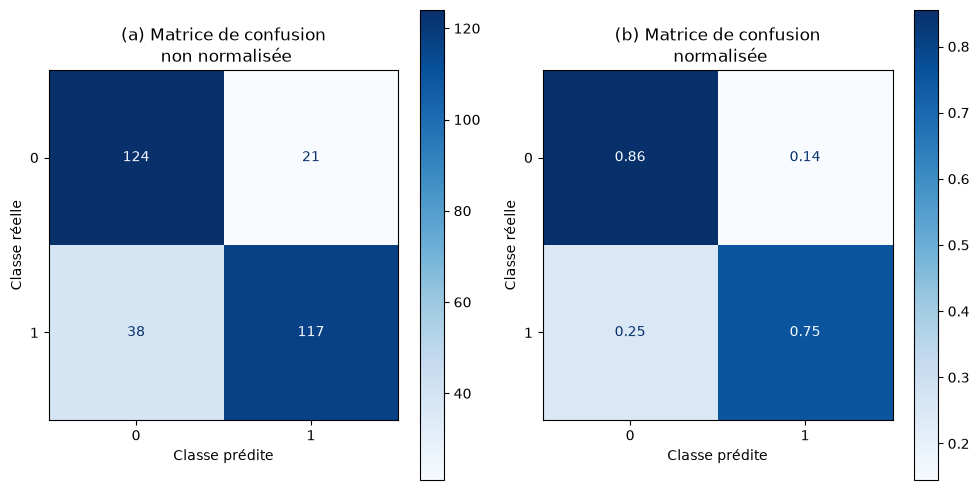

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)

# Normalisation de la matrice de confusion (par ligne)
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

# Création des sous-graphiques
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Affichage de la matrice de confusion (non normalisée)
disp1 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp1.plot(cmap='Blues', ax=ax[0])
ax[0].set_title("(a) Matrice de confusion\n non normalisée")

# Affichage de la matrice de confusion normalisée
disp2 = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_normalized)
disp2.plot(cmap='Blues', ax=ax[1])
ax[1].set_title("(b) Matrice de confusion\n normalisée")

for disp, a in ((disp1, ax[0]), (disp2, ax[1])):
    a.set_xlabel("Classe prédite")
    a.set_ylabel("Classe réelle")

fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Chap1_MatNormalized")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.8 : Courbe ROC et calcul de l'AUC</h3>

AUC : 0.87


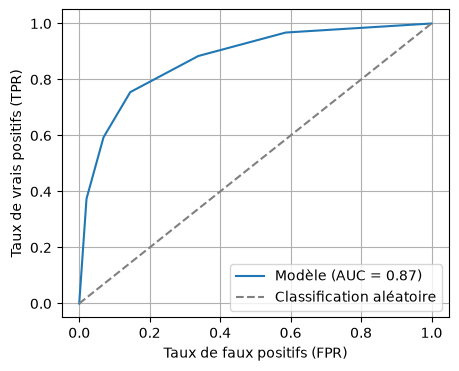

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score

# Points de la courbe ROC (FPR, TPR) pour chaque seuil de décision
fpr, tpr, seuils = roc_curve(y_test, y_pred_proba)

# Aire sous la courbe (AUC)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC : {auc:.2f}")

# Tracé de la courbe ROC
fig = plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"Modèle (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray',
    label="Classification aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend()
plt.grid(True)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap1_ROC")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.9 : Regroupement des données via l'algorithme $k$-means</h3>

In [11]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Fixer la graine aléatoire pour la reproductibilité
np.random.seed(42)

# Générer des données synthétiques
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

# Appliquer le clustering avec K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

C:\Users\askar\anaconda3\envs\livre_am_ed1_py312\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 1.10 : Métriques d'évaluation des regroupements</h3>

In [12]:
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.metrics import davies_bouldin_score

# Indice de Silhouette
silhouette_avg = silhouette_score(X, y_kmeans)
print(f"Indice de silhouette : {silhouette_avg:.2f}")

# Cohésion intra-cluster
#   - moyenne des distances entre les points et leurs centres
distances = np.linalg.norm(X - kmeans.cluster_centers_[y_kmeans], axis=1)
cohesion = np.mean(distances)
print(f"Cohésion intra-cluster (distance moyenne) : {cohesion:.2f}")

# Séparation inter-cluster
#   - moyenne des distances entre les centres des clusters
centroid_distances = pairwise_distances(kmeans.cluster_centers_)
np.fill_diagonal(centroid_distances, np.nan)
separation = np.nanmean(centroid_distances)
print(f"Séparation inter-cluster (distance moyenne entre les centres) : {separation:.2f}")

# Davies-Bouldin Index
db_index = davies_bouldin_score(X, y_kmeans)
print(f"Indice Davies-Bouldin : {db_index:.2f}")

Indice de silhouette : 0.75
Cohésion intra-cluster (distance moyenne) : 1.46
Séparation inter-cluster (distance moyenne entre les centres) : 12.69
Indice Davies-Bouldin : 0.35


<h3><span style="font-size: 30px">&#127924;</span> Figure : Visualisation des clusters et de leurs centroïdes</h3>

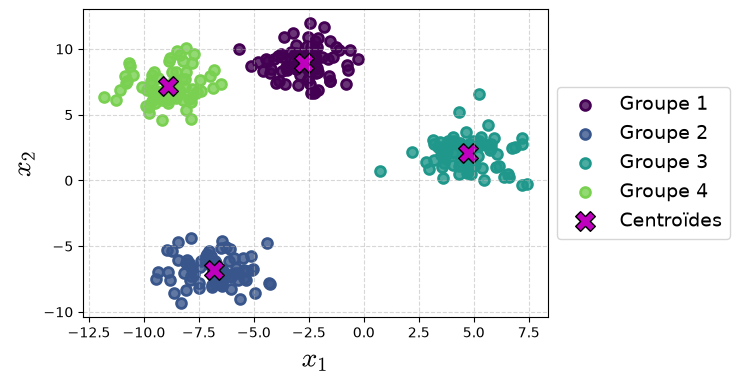

In [13]:
# Visualisation des clusters et de leurs centroïdes
fig = plt.figure(figsize=(6, 4))

# on prend 4 couleurs sur la palette viridis (une par groupe)
couleurs = plt.cm.viridis(np.linspace(0, 0.8, 4))

# on trace chaque groupe séparément pour avoir une légende par groupe
for i in range(4):
    couleur_remplissage = couleurs[i].copy()
    couleur_remplissage[3] = 0.8  # transparence uniquement sur le remplissage
    
    plt.scatter(
        X[y_kmeans == i, 0], X[y_kmeans == i, 1],
        s=50, color=couleur_remplissage, linewidth=2,
        edgecolor=couleurs[i], label=f'Groupe {i + 1}'
    )
plt.xlabel(f"$x_1$", fontsize=20)
plt.ylabel(f"$x_2$", fontsize=20)
# les centroïdes (croix noires)
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    marker='X', edgecolor='black', color='#bf00bf', s=200, label='Centroïdes'
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=14, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0., frameon=True)

# Sauvegarder la figure
save_figure(fig, "Figures/Chap1_plot_clusters")

plt.show()

<hr style='border-top:4px solid #1F77B4;'>